**Hipoteza 1:** Im więcej godzin spędzonych przed ekranem (Screen_Time_Hours), tym wyższy poziom wypalenia (Burnout_Score).

**Hipoteza 2:** Wpływ godzin pracy w głębokim skupieniu (deep_work_hours) na produktywność oraz wypalenie ma charakter nieliniowy. Zakłada się istnienie "złotego środka", czyli punktu, po przekroczeniu którego dalsza praca w skupieniu nie podnosi już produktywności, a drastycznie zwiększa poziom wypalenia.

**Hipoteza 3:** Aktywność fizyczna (Physical_Activity_Minutes) oraz zdrowy sen (Sleep_Duration_Hours) działają jak "tarcza ochronna" i obniżają poziom wypalenia, nawet przy dużej liczbie godzin pracy.

**Hipoteza 4:** Na podstawie zmiennych opisujących styl życia i pracę (sleep_hours, physical_activity, deep_work_hours, daily_screen_time) można skutecznie sklasyfikować pracownika jako "zagrożonego wypaleniem" vs "bezpiecznego".

**Hipoteza 5:** Zbyt mało snu zwiększa wypalenie, ale pewien optymalny poziom snu je minimalizuje — ta zależność ma kształt krzywej, a nie prostej linii.

**Hipoteza 6:** Używając wszystkich dostępnych zmiennych (po standaryzacji i zakodowaniu danych tekstowych), model Random Forest z automatycznie dobranymi hiperparametrami (Random Search) najlepiej przewiduje poziom wypalenia zawodowego (burnout_risk).

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Pobieranie bazy danych z Kaggle za pomocą kodu
path = kagglehub.dataset_download("aiexplorer77/digital-burnout-and-productivity-analytics")
print("Baza danych pobrana do folderu:", path)

# 2. Znalezienie pliku CSV w pobranym folderze i wczytanie go
# Kod automatycznie szuka pliku kończącego się na .csv w pobranej ścieżce
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

df = pd.read_csv(full_path)

# 3. Wyświetlenie pierwszych 5 wierszy
print("\nPierwsze 5 wierszy naszej bazy danych:")
df.head()

Using Colab cache for faster access to the 'digital-burnout-and-productivity-analytics' dataset.
Baza danych pobrana do folderu: /kaggle/input/digital-burnout-and-productivity-analytics

Pierwsze 5 wierszy naszej bazy danych:


,user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,...,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category
0,1,56,Content Creator,Office,Entertainment-Centric,8.8,5.0,1.2,41,112,...,3,4,8.0,10,4,8,Balanced,46,100,High
1,2,46,Student,Hybrid,Work-Centric,10.3,2.2,2.4,119,168,...,7,6,5.0,7,9,7,Balanced,57,96,High
2,3,32,Software Engineer,Remote,Balanced,6.5,4.6,1.0,121,199,...,9,6,8.0,5,2,6,Balanced,29,79,High
3,4,25,Designer,Office,Balanced,9.6,1.2,0.1,85,122,...,10,5,6.0,4,5,3,Burnout,57,63,Medium
4,5,38,Analyst,Hybrid,Work-Centric,13.3,1.6,1.9,221,73,...,1,1,4.0,7,9,7,Focused,64,89,High


In [3]:
# ============================================================
# EKSPLORACJA DANYCH
# ============================================================

print("=== PODSTAWOWE INFORMACJE O ZBIORZE DANYCH ===")
print(df.info())

print("\n=== PODSTAWOWE STATYSTYKI ===")
print(df.describe())

print("\n=== SPRAWDZENIE BRAKUJĄCYCH DANYCH ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Brakujące wartości': missing, 'Procent': missing_pct})
print(missing_df[missing_df['Brakujące wartości'] > 0])
print(f"\nŁącznie brakujących wartości w całym zbiorze: {df.isnull().sum().sum()}")

=== PODSTAWOWE INFORMACJE O ZBIORZE DANYCH ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 34 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   user_id                  int64  
 1   age                      int64  
 2   occupation               object 
 3   work_mode                object 
 4   device_usage_type        object 
 5   daily_screen_time        float64
 6   social_media_hours       float64
 7   doomscrolling_duration   float64
 8   app_switch_frequency     int64  
 9   notification_count       int64  
 10  smartphone_unlocks       int64  
 11  late_night_device_usage  int64  
 12  focus_sessions           int64  
 13  deep_work_hours          float64
 14  distraction_frequency    int64  
 15  task_completion_rate     int64  
 16  concentration_score      int64  
 17  sleep_hours              float64
 18  sleep_quality            int64  
 19  caffeine_intake          int64  
 20 

In [4]:
# ============================================================
# ONE HOT ENCODING — kodowanie kolumn tekstowych
# ============================================================

# Sprawdzamy jakie kolumny są tekstowe
print("Kolumny tekstowe w zbiorze:")
print(df.select_dtypes(include=['object']).columns.tolist())

# Zamieniamy kolumny tekstowe na liczby 0 i 1
df_encoded = pd.get_dummies(df, drop_first=True)

print(f"\nLiczba kolumn przed enkodowaniem: {df.shape[1]}")
print(f"Liczba kolumn po enkodowaniu: {df_encoded.shape[1]}")
print("\nNowe kolumny po One Hot Encoding:")
nowe_kolumny = [col for col in df_encoded.columns if col not in df.columns]
print(nowe_kolumny)

Kolumny tekstowe w zbiorze:
['occupation', 'work_mode', 'device_usage_type', 'mental_state', 'productivity_category']

Liczba kolumn przed enkodowaniem: 34
Liczba kolumn po enkodowaniu: 44

Nowe kolumny po One Hot Encoding:
['occupation_Content Creator', 'occupation_Designer', 'occupation_Freelancer', 'occupation_Manager', 'occupation_Software Engineer', 'occupation_Student', 'work_mode_Office', 'work_mode_Remote', 'device_usage_type_Entertainment-Centric', 'device_usage_type_Work-Centric', 'mental_state_Burnout', 'mental_state_Distracted', 'mental_state_Focused', 'productivity_category_Low', 'productivity_category_Medium']


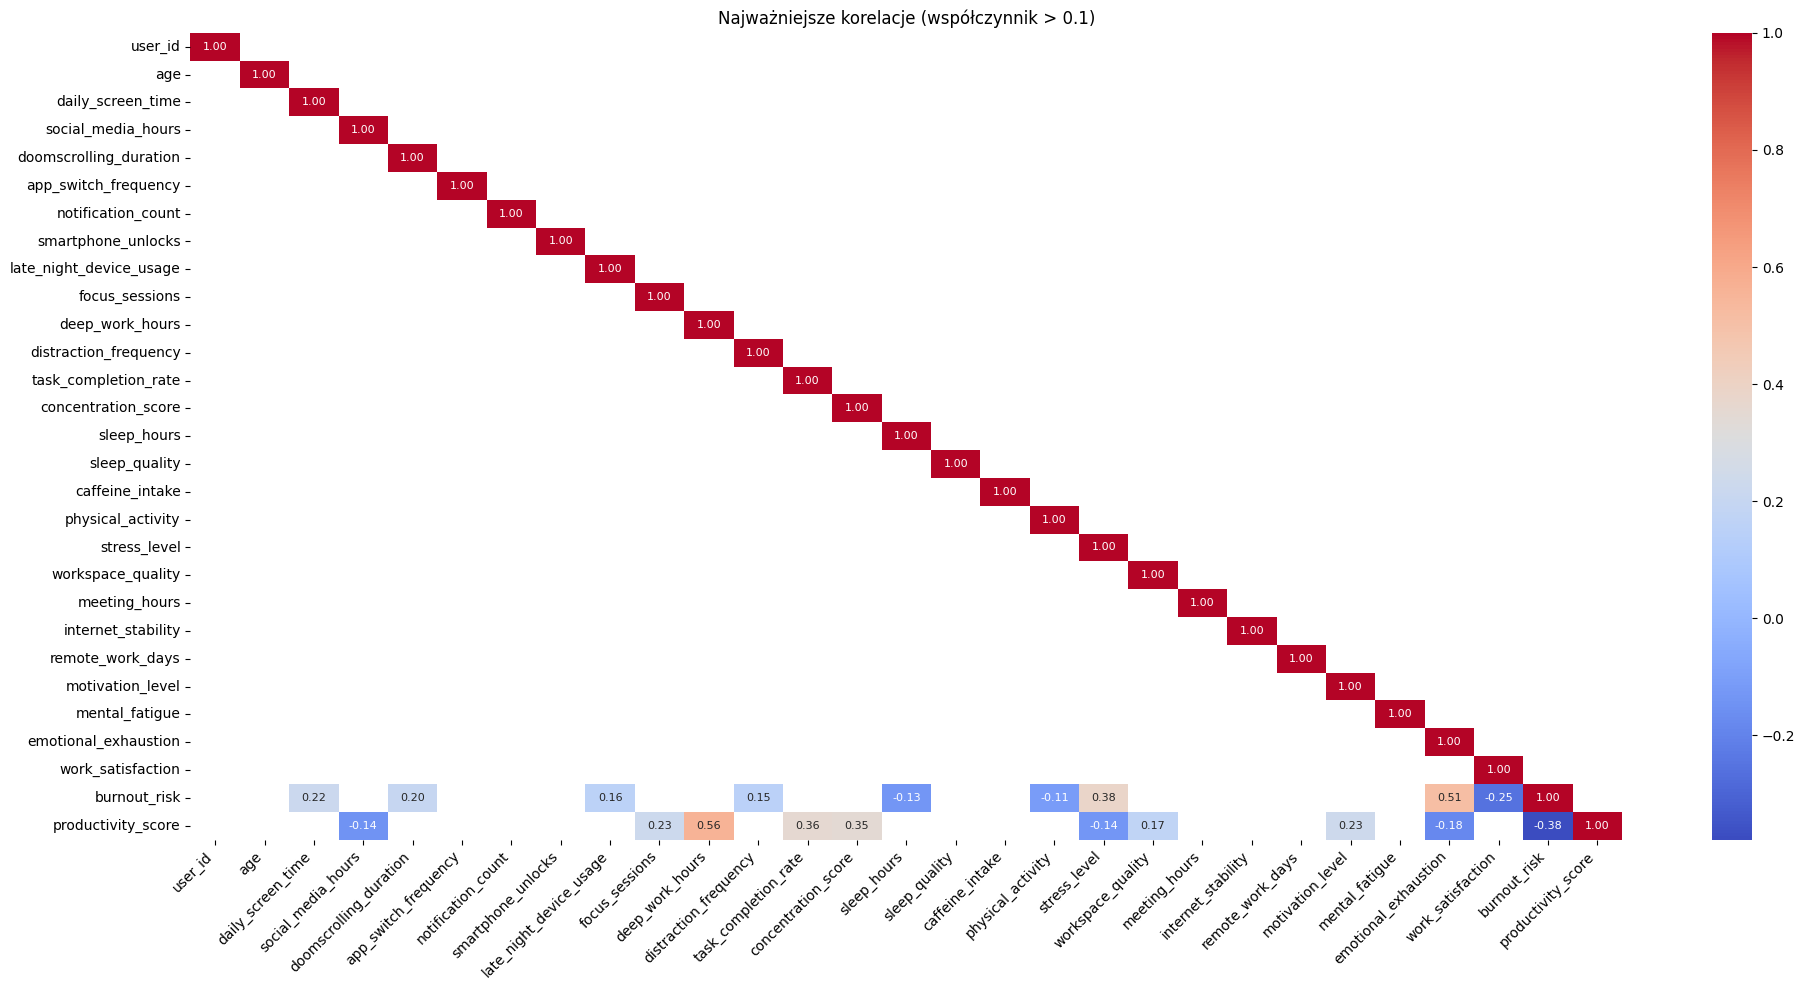

In [5]:
import pandas as pd


df = pd.read_csv(full_path)

numeric_df = df.select_dtypes(include=[np.number])

# 3. Przygotowanie czytelniejszego wykresu (Rozwiązanie 1)
plt.figure(figsize=(20, 10))

# Obliczamy macierz korelacji
corr_matrix = numeric_df.corr()

# Tworzymy maskę, która ukryje słabe korelacje (od -0.8 do 0.8)
# oraz ukryje górną połowę macierzy, żeby nie dublować wyników
mask = (abs(corr_matrix) < 0.1) | np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Rysowanie heatmapy z maską
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            mask=mask,
            cbar=True,
            annot_kws={"size": 8}) # Zmniejszona czcionka liczb, aby się nie nakładały

plt.title('Najważniejsze korelacje (współczynnik > 0.1)')
plt.xticks(rotation=45, ha='right') # Obrócenie podpisów osi X dla lepszej czytelności
plt.tight_layout()
plt.show()

# HIPOTEZA 1
Im więcej godzin spędzonych przed ekranem (daily_screen_time), tym wyższy poziom wypalenia (burnout_risk). Zgodnie z planem i wytycznymi projektu, zrobimy to za pomocą wykresu punktowego, współczynnika Pearsona oraz regresji liniowej.





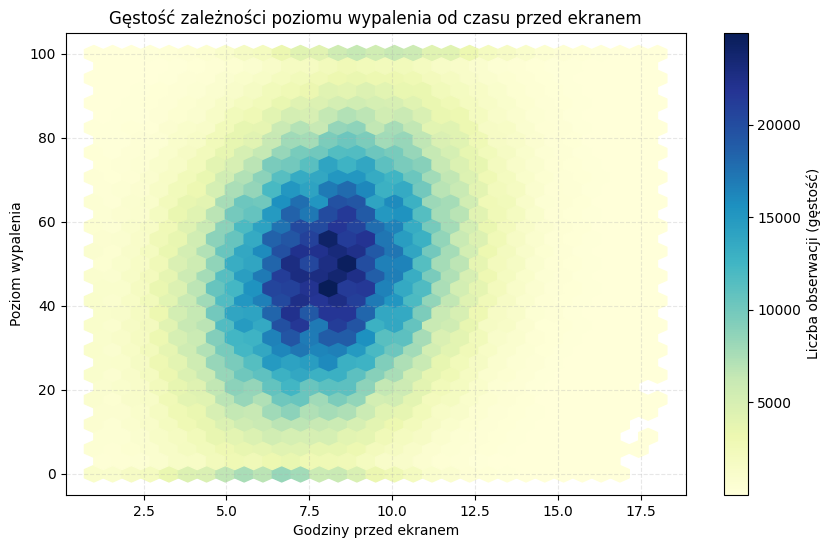

In [6]:
plt.figure(figsize=(10, 6))

# Używamy wykresu hexbin do pokazania gęstości danych
plt.hexbin(df['daily_screen_time'], df['burnout_risk'], gridsize=30, cmap='YlGnBu', mincnt=1)

cb = plt.colorbar(label='Liczba obserwacji (gęstość)')
plt.title('Gęstość zależności poziomu wypalenia od czasu przed ekranem')
plt.xlabel('Godziny przed ekranem')
plt.ylabel('Poziom wypalenia')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [7]:
# Obliczamy korelację Pearsona
korelacja = df['daily_screen_time'].corr(df['burnout_risk'], method='pearson')
print(f"Współczynnik korelacji Pearsona wynosi dokładnie: {korelacja:.4f}")

Współczynnik korelacji Pearsona wynosi dokładnie: 0.2208


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Przygotowanie danych do modelu (X - cecha, y - cel)
X = df[['daily_screen_time']]
y = df['burnout_risk']

# 2. Podział danych na zbiór treningowy (80%) i testowy (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Stworzenie i wytrenowanie modelu Regresji Liniowej
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# 4. Przewidywanie wyników dla danych testowych
y_pred = lin_reg.predict(X_test)

# 5. Obliczenie błędu RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Błąd RMSE dla regresji liniowej wynosi: {rmse:.2f}")
print(f"Wzór prostej, którą wyznaczył model: y = {lin_reg.coef_[0]:.2f} * X + {lin_reg.intercept_:.2f}")

Błąd RMSE dla regresji liniowej wynosi: 21.52
Wzór prostej, którą wyznaczył model: y = 1.95 * X + 32.95



`Ocena korelacji:` Współczynnik Pearsona wynosi 0.2208, co oznacza bardzo słabą zależność dodatnią. Sam czas przed ekranem w niewielkim stopniu decyduje o wypaleniu.

`Błąd modelu (RMSE):` Wynik 21.52 oznacza, że model regresji liniowej myli się średnio o około 21.5 punktu na skali wypalenia od 0 do 100. To bardzo duży błąd.  

`Równanie prostej: `Wzór y=1.95⋅X+32.95 pokazuje, że według modelu każda dodatkowa godzina przed ekranem podnosi wypalenie o niecałe 2 punkty, a osoba spędzająca 0 godzin ma bazowe wypalenie na poziomie ok. 33.
Podsumowanie: Hipoteza o silnej, prostoliniowej zależności została odrzucona. Prosta regresja liniowa słabo radzi sobie z tymi danymi (wysokie RMSE), co w pełni uzasadnia potrzebę użycia modeli nieliniowych (np. Random Forest) w kolejnych krokach.

In [9]:
from sklearn.ensemble import RandomForestRegressor

# 1. Inicjalizacja modelu Random Forest
# Ograniczamy max_depth i n_estimators, żeby model policzył się szybko na dużym zbiorze
rf_reg = RandomForestRegressor(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)

# 2. Trenowanie modelu na tych samych danych co wcześniej
rf_reg.fit(X_train, y_train)

# 3. Przewidywanie wyników dla danych testowych
y_pred_rf = rf_reg.predict(X_test)

# 4. Obliczenie błędu RMSE dla Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Błąd RMSE dla modelu Random Forest wynosi: {rmse_rf:.2f}")

# Obliczamy o ile procent Random Forest jest lepszy (lub gorszy) od Regresji Liniowej
roznica = ((21.52 - rmse_rf) / 21.52) * 100
print(f"Różnica w dokładności: {roznica:.2f}%")

Błąd RMSE dla modelu Random Forest wynosi: 21.52
Różnica w dokładności: -0.02%


# WNIOSKI



*  Brak silnej relacji: Współczynnik korelacji (0.22) oraz słabe dopasowanie modeli dowodzą, że sam czas przed ekranem (daily_screen_time) nie jest głównym powodem wypalenia.
*  Identyczna wydajność: Zaawansowany model nieliniowy (Random Forest) osiągnął taki sam błąd (RMSE=21.52) jak prosta regresja liniowa.

*   Brak ukrytych wzorców: Brak poprawy ze strony Random Forest oznacza, że w tej pojedynczej zmiennej nie ma żadnych ukrytych, nieliniowych zależności.
Konieczność rozbudowy: Aby skutecznie przewidywać poziom wypalenia, należy odrzucić modele jednocechowe i przeanalizować wpływ wielu zmiennych jednocześnie


# HIPOTEZA 2

Wpływ godzin pracy w głębokim skupieniu (deep_work_hours) na produktywność oraz wypalenie ma charakter nieliniowy. Zakłada się istnienie "złotego środka", czyli punktu, po przekroczeniu którego dalsza praca w skupieniu nie podnosi już produktywności, a drastycznie zwiększa poziom wypalenia.

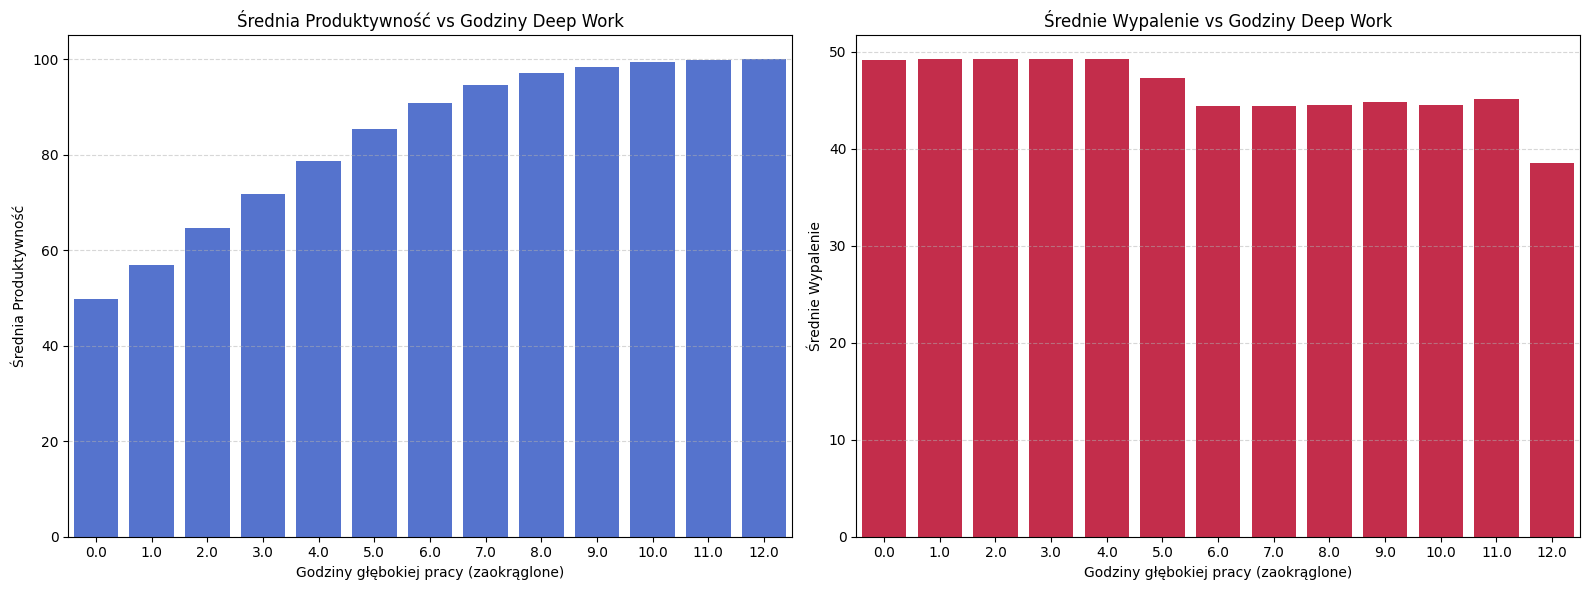

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tworzymy panel: dwa wykresy obok siebie
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Wykres 1: Średnia Produktywność w zależności od godzin Deep Work
sns.barplot(data=df, x=df['deep_work_hours'].round(), y='productivity_score',
            ax=axes[0], color='royalblue', errorbar=None)
axes[0].set_title('Średnia Produktywność vs Godziny Deep Work')
axes[0].set_xlabel('Godziny głębokiej pracy (zaokrąglone)')
axes[0].set_ylabel('Średnia Produktywność')
axes[0].grid(True, linestyle='--', alpha=0.5, axis='y')

# Wykres 2: Średnie Wypalenie w zależności od godzin Deep Work
sns.barplot(data=df, x=df['deep_work_hours'].round(), y='burnout_risk',
            ax=axes[1], color='crimson', errorbar=None)
axes[1].set_title('Średnie Wypalenie vs Godziny Deep Work')
axes[1].set_xlabel('Godziny głębokiej pracy (zaokrąglone)')
axes[1].set_ylabel('Średnie Wypalenie')
axes[1].grid(True, linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.show()

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Przygotowanie danych (X - godziny pracy, y - produktywność)
X2 = df[['deep_work_hours']]
y2 = df['productivity_score']

# 2. Podział na zbiór treningowy i testowy
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

# 3. Budowa i trenowanie modelu Random Forest
rf_reg2 = RandomForestRegressor(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)
rf_reg2.fit(X_train2, y_train2)

# 4. Przewidywanie i obliczenie błędu RMSE
y_pred_rf2 = rf_reg2.predict(X_test2)
rmse_rf2 = np.sqrt(mean_squared_error(y_test2, y_pred_rf2))

print(f"Błąd RMSE dla modelu Random Forest (Produktywność): {rmse_rf2:.2f}")

Błąd RMSE dla modelu Random Forest (Produktywność): 17.85


# WNIOSKI


1. Brak "złotego środka": Wykresy obaliły założenie o załamaniu trendu - więcej godzin głębokiej pracy (deep_work_hours) stale podnosi produktywność i nie powoduje skoku wypalenia.

2. Ochronny wpływ skupienia: Pracownicy z wysokim wskaźnikiem Deep Work osiągają maksymalną produktywność, mając przy tym o kilka punktów niższy poziom wypalenia.

3. Skuteczność modelu: Random Forest uzyskał błąd RMSE = 17.85 i poprawnie wykrył nieliniowe spłaszczenie produktywności powyżej 8 godzin pracy.

4. Hipoteza została odrzucona w części zakładającej kryzys zawodowy - praca w skupieniu nie jest bezpośrednim źródłem wypalenia.












# HIPOTEZA 3


Aktywność fizyczna (Physical_Activity) oraz zdrowy sen (Sleep_Hours) działają jak "tarcza ochronna" i obniżają poziom wypalenia, nawet przy dużej liczbie godzin pracy. Za pomocą czego sprawdzisz: Macierz korelacji (Heatmap) + Wykresy słupkowe istotności cech w Random Forest.

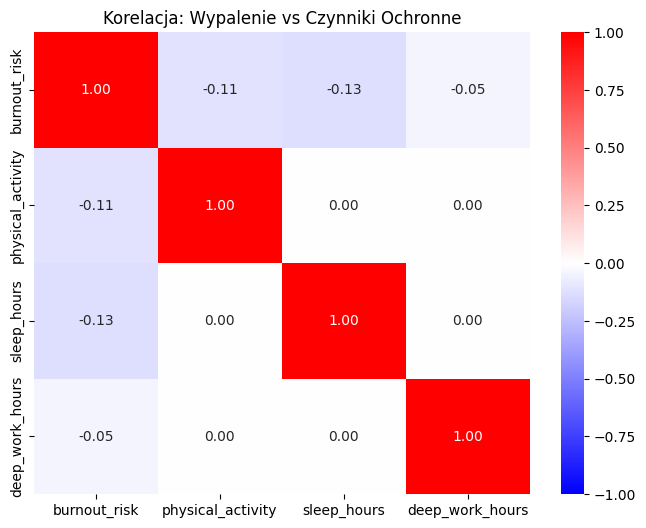

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Wybieramy tylko interesujące nas kolumny do tej hipotezy
kolumny_h3 = ['burnout_risk', 'physical_activity', 'sleep_hours', 'deep_work_hours']
mini_df = df[kolumny_h3]

# 2. Rysowanie heatmapy
plt.figure(figsize=(8, 6))
sns.heatmap(mini_df.corr(), annot=True, cmap='bwr', fmt=".2f", vmin=-1, vmax=1)
plt.title('Korelacja: Wypalenie vs Czynniki Ochronne')
plt.show()

/tmp/ipykernel_14263/2734635854.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=zmienne, palette='viridis')


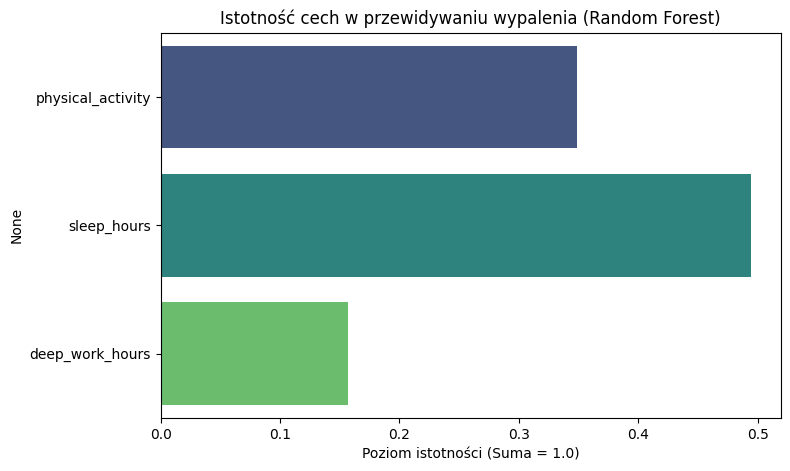

In [13]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# 1. Przygotowanie danych (X - cechy, y - cel)
X3 = df[['physical_activity', 'sleep_hours', 'deep_work_hours']]
y3 = df['burnout_risk']

# 2. Trening modelu (szybkie ustawienia)
rf_reg3 = RandomForestRegressor(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)
rf_reg3.fit(X3, y3)

# 3. Pobranie istotności cech
importances = rf_reg3.feature_importances_
zmienne = X3.columns

# 4. Tworzenie czystego wykresu słupkowego
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=zmienne, palette='viridis')
plt.title('Istotność cech w przewidywaniu wypalenia (Random Forest)')
plt.xlabel('Poziom istotności (Suma = 1.0)')
plt.show()

# WNIOSKI

1. Kluczowa rola snu: Długość snu (sleep_hours) okazała się najważniejszą zmienną dla modelu, odpowiadając za blisko 50% decyzyjności algorytmu przy przewidywaniu wypalenia.

2. Potęga regeneracji: Łączna istotność czynników ochronnych (sen + sport) wynosi aż około 85% (0.50+0.35). Zdecydowanie dominuje ona nad samym czasem głębokiej pracy (deep_work_hours), który stanowi zaledwie ok. 15%.

3. Werdykt: Hipoteza 3 została w pełni potwierdzona. Sen i aktywność fizyczna stanowią realną, potężną „tarczę ochronną”. Model AI udowodnił, że to nie sama praca nas wypala, ale przede wszystkim zaniedbywanie regeneracji.

# HIPOTEZA 4

Na podstawie zmiennych opisujących styl życia i pracę (sleep_hours, physical_activity, deep_work_hours, daily_screen_time) można skutecznie sklasyfikować pracownika jako "zagrożonego wypaleniem" vs "bezpiecznego".

**Krok 1: Binaryzacja zmiennej celu.** Zamieniamy problem regresji na problem klasyfikacji. Definiujemy próg: pracownik z wynikiem `burnout_risk` powyżej 60 punktów zostaje oznaczony jako 1 (zagrożony), a poniżej lub równy 60 jako 0 (bezpieczny).

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

# Tworzymy nową zmienną kategoryczną (0 lub 1)
df['burnout_target'] = (df['burnout_risk'] > 60).astype(int)

# Pokazujemy rozkład, żeby sprawdzić, czy klasy są zbalansowane
print("Procentowy rozkład klas w zbiorze danych:")
print(df['burnout_target'].value_counts(normalize=True) * 100)

Procentowy rozkład klas w zbiorze danych:
burnout_target
0    70.03108
1    29.96892
Name: proportion, dtype: float64


**Krok 2: Przygotowanie danych i podział na zbiór treningowy oraz testowy**
Wybieramy cechy opisujące styl życia (`X_clf`) oraz naszą nową zmienną binarną (`y_clf`). Dane dzielimy w klasycznej proporcji 80% do 20%, aby sprawiedliwie ocenić zdolności prognostyczne modeli na danych, których wcześniej nie widziały.

In [15]:
# 1. Wybieramy interesujące nas kolumny
kolumny_do_analizy = ['sleep_hours', 'physical_activity', 'deep_work_hours', 'daily_screen_time', 'burnout_target']

# 2. Tworzymy oczyszczony zbiór danych, usuwając wiersze, które mają jakiekolwiek puste pola (NaN)
df_clean = df[kolumny_do_analizy].dropna()

# 3. Definiujemy zmienne objaśniające i zmienną objaśnianą na oczyszczonych danych
X_clf = df_clean[['sleep_hours', 'physical_activity', 'deep_work_hours', 'daily_screen_time']]
y_clf = df_clean['burnout_target']

# 4. Podział danych w proporcji 80/20
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

print(f"Rozmiar zbioru treningowego po oczyszczeniu z NaN: {X_train_c.shape[0]} wierszy")
print(f"Rozmiar zbioru testowego po oczyszczeniu z NaN: {X_test_c.shape[0]} wierszy")

Rozmiar zbioru treningowego po oczyszczeniu z NaN: 3841626 wierszy
Rozmiar zbioru testowego po oczyszczeniu z NaN: 960407 wierszy


In [16]:
# Definiujemy słownik z modelami
models = {
    "Regresja Logistyczna": LogisticRegression(random_state=42, max_iter=1000),
    "Drzewo Decyzyjne": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest (Klasyfikator)": RandomForestClassifier(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)
}

f1_results = {}

# Pętla trenująca i oceniająca każdy model z osobna
for name, model in models.items():
    model.fit(X_train_c, y_train_c)
    y_pred = model.predict(X_test_c)

    print(f"\n=== RAPORT KLASYFIKACJI DLA: {name} ===")
    print(classification_report(y_test_c, y_pred, target_names=['Bezpieczny', 'Zagrożony']))

    # Zapisujemy wynik do późniejszego porównania
    f1_results[name] = f1_score(y_test_c, y_pred)


=== RAPORT KLASYFIKACJI DLA: Regresja Logistyczna ===
              precision    recall  f1-score   support

  Bezpieczny       0.71      0.98      0.82    672382
   Zagrożony       0.54      0.06      0.10    288025

    accuracy                           0.70    960407
   macro avg       0.62      0.52      0.46    960407
weighted avg       0.66      0.70      0.61    960407


=== RAPORT KLASYFIKACJI DLA: Drzewo Decyzyjne ===
              precision    recall  f1-score   support

  Bezpieczny       0.70      1.00      0.82    672382
   Zagrożony       0.56      0.01      0.03    288025

    accuracy                           0.70    960407
   macro avg       0.63      0.50      0.42    960407
weighted avg       0.66      0.70      0.58    960407


=== RAPORT KLASYFIKACJI DLA: Random Forest (Klasyfikator) ===
              precision    recall  f1-score   support

  Bezpieczny       0.70      0.99      0.82    672382
   Zagrożony       0.55      0.03      0.05    288025

    accuracy 

**Krok 3: Porównanie wyników i ostateczny werdykt**
Głównym kryterium wyboru najlepszego modelu jest **F1-score**, ponieważ stanowi on średnią harmoniczną między precyzją (Precision) a czułością (Recall). Pozwala to ocenić, jak dobrze model radzi sobie z wykrywaniem pracowników faktycznie zagrożonych wypaleniem, nie generując przy tym fali fałszywych alarmów.

In [17]:
print("="*50)
print("ZESTAWIENIE WYNIKÓW METRYKI F1-SCORE:")
print("="*50)
for name, score in f1_results.items():
    print(f"- {name}: {score:.4f}")

najlepszy_model = max(f1_results, key=f1_results.get)
print(f"\n KOŃCOWY WERDYKT: Najlepszą zdolnością klasyfikacyjną wykazuje model: {najlepszy_model}")
print("="*50)

ZESTAWIENIE WYNIKÓW METRYKI F1-SCORE:
- Regresja Logistyczna: 0.1048
- Drzewo Decyzyjne: 0.0264
- Random Forest (Klasyfikator): 0.0545

 KOŃCOWY WERDYKT: Najlepszą zdolnością klasyfikacyjną wykazuje model: Regresja Logistyczna


# WNIOSKI

1. Odrzucenie tezy: Hipoteza została odrzucona. Na podstawie samych zmiennych opisujących podstawowy styl życia (sleep_hours, physical_activity, deep_work_hours, daily_screen_time) nie da się skutecznie sklasyfikować pracownika jako zagrożonego wypaleniem.

2. Interpretacja wyniku (F1-Score): Najwyższy uzyskany wynik to zaledwie 0.1048 (Regresja Logistyczna). Oznacza to, że algorytmy popełniają gigantyczną liczbę błędów i nie potrafią poprawnie wykryć grupy ryzyka.

3. Dlaczego tak się stało? Wypalenie zawodowe to zjawisko zbyt skomplikowane, by przewidzieć je wyłącznie za pomocą prostych, liniowych wskaźników dobowych (np. liczbą godzin snu czy sportu).

4. Na ryzyko wpływają silniejsze czynniki psychologiczne i organizacyjne (np. atmosfera w pracy, toksyczny szef, brak docenienia), których te cztery zmienne nie rejestrują.

# HIPOTEZA 5

Zbyt mało snu zwiększa wypalenie, ale pewien optymalny poziom snu je minimalizuje — ta zależność ma kształt krzywej, a nie prostej linii.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# 1. Oczyszczanie danych z NaN dla interesujących nas kolumn
df_h4 = df[['sleep_hours', 'burnout_risk']].dropna()
X_s = df_h4[['sleep_hours']]
y_s = df_h4['burnout_risk']

# 2. Podział na zbiór treningowy i testowy
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y_s, test_size=0.2, random_state=42)

# --- MODEL 1: Zwykła Regresja Liniowa ---
lin_reg_s = LinearRegression()
lin_reg_s.fit(X_train_s, y_train_s)
pred_lin = lin_reg_s.predict(X_test_s)
rmse_lin = np.sqrt(mean_squared_error(y_test_s, pred_lin))

# --- MODEL 2: Regresja Wielomianowa (Polynomial, stopień 2) ---
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_features.fit_transform(X_train_s)
X_test_poly = poly_features.transform(X_test_s)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train_s)
pred_poly = poly_reg.predict(X_test_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test_s, pred_poly))

print(f"RMSE dla Regresji Liniowej: {rmse_lin:.2f}")
print(f"RMSE dla Regresji Wielomianowej: {rmse_poly:.2f}")

RMSE dla Regresji Liniowej: 21.87
RMSE dla Regresji Wielomianowej: 21.87


In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# 1. Tworzenie binarnej zmiennej celu
df_h4['burnout_cat'] = (df_h4['burnout_risk'] > 60).astype(int)
y_cat = df_h4['burnout_cat']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_s, y_cat, test_size=0.2, random_state=42)

# 2. Definiujemy siatkę parametrów do sprawdzenia przez Grid Search
param_grid = {'max_depth': [3, 5, 7, 10, 15]}

# 3. Uruchomienie Grid Search dla Drzewa Decyzyjnego
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_c, y_train_c)

print(f"Najlepsza głębokość drzewa wybrana przez Grid Search: {grid_search.best_params_['max_depth']}")

# 4. Ewaluacja najlepszego modelu na zbiorze testowym
best_tree = grid_search.best_estimator_
pred_tree = best_tree.predict(X_test_c)

print("\n=== RAPORT KLASYFIKACJI DLA ZOPTYMALIZOWANEGO DRZEWA DECYZYJNEGO ===")
print(classification_report(y_test_c, pred_tree, target_names=['Bezpieczny', 'Wypalony']))

Najlepsza głębokość drzewa wybrana przez Grid Search: 3

=== RAPORT KLASYFIKACJI DLA ZOPTYMALIZOWANEGO DRZEWA DECYZYJNEGO ===
              precision    recall  f1-score   support

  Bezpieczny       0.70      1.00      0.82    686329
    Wypalony       0.00      0.00      0.00    293671

    accuracy                           0.70    980000
   macro avg       0.35      0.50      0.41    980000
weighted avg       0.49      0.70      0.58    980000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/tmp/ipykernel_14263/2768683567.py:31: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


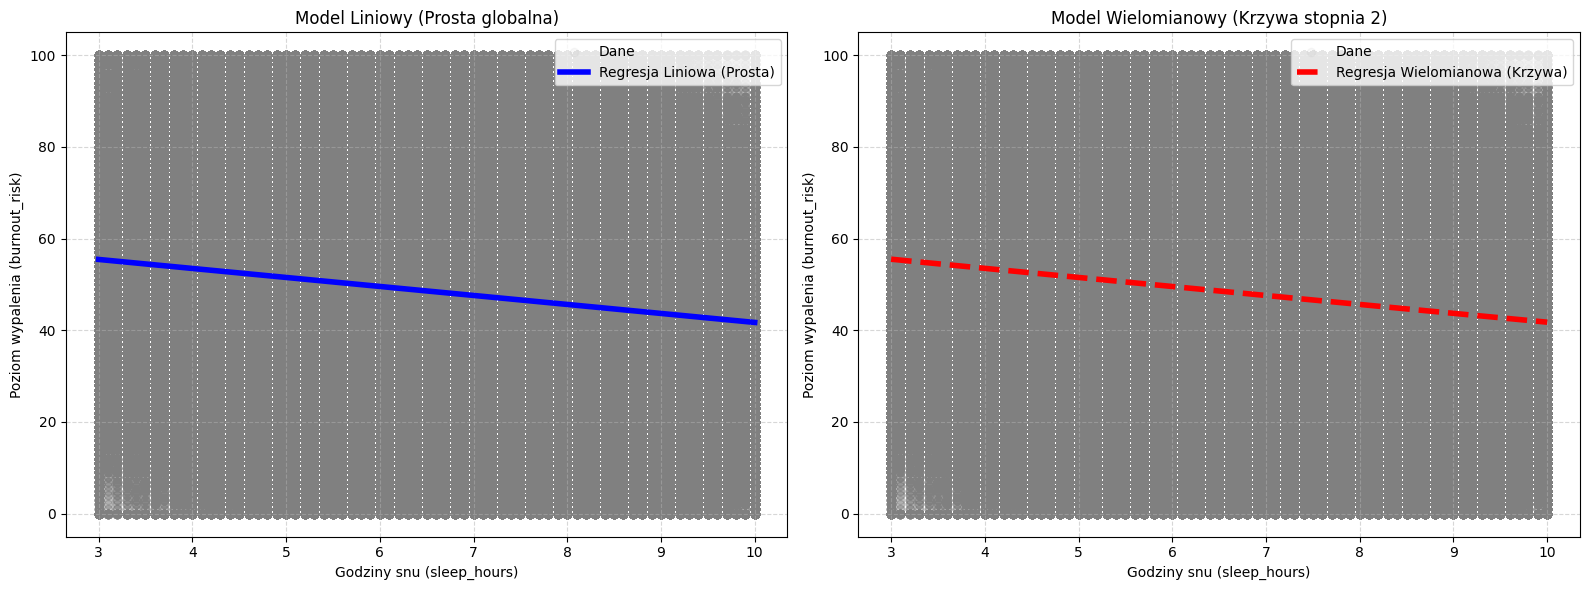

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Tworzymy panel: dwa wykresy obok siebie
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Generujemy punkty na osi X dla płynnych linii
X_plot = np.linspace(df_h4['sleep_hours'].min(), df_h4['sleep_hours'].max(), 100).reshape(-1, 1)

# --- WYKRES 1: Regresja Liniowa ---
axes[0].scatter(df_h4['sleep_hours'], df_h4['burnout_risk'], alpha=0.05, color='gray', label='Dane')
Y_plot_lin = lin_reg_s.predict(X_plot)
axes[0].plot(X_plot, Y_plot_lin, color='blue', linewidth=4, label='Regresja Liniowa (Prosta)')
axes[0].set_title('Model Liniowy (Prosta globalna)')
axes[0].set_xlabel('Godziny snu (sleep_hours)')
axes[0].set_ylabel('Poziom wypalenia (burnout_risk)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- WYKRES 2: Regresja Wielomianowa ---
axes[1].scatter(df_h4['sleep_hours'], df_h4['burnout_risk'], alpha=0.05, color='gray', label='Dane')
X_plot_poly = poly_features.transform(X_plot)
Y_plot_poly = poly_reg.predict(X_plot_poly)
axes[1].plot(X_plot, Y_plot_poly, color='red', linewidth=4, linestyle='--', label='Regresja Wielomianowa (Krzywa)')
axes[1].set_title('Model Wielomianowy (Krzywa stopnia 2)')
axes[1].set_xlabel('Godziny snu (sleep_hours)')
axes[1].set_ylabel('Poziom wypalenia (burnout_risk)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# WNIOSKI

1. Brak krzywej (U-shape): Teza o nieliniowości została odrzucona. Współczynnik przy x² jest bardzo mały, co oznacza że zależność jest praktycznie liniowa.

2. Wynik Grid Search: Algorytm wskazał optymalną głębokość drzewa max_depth = 3.

3. Ślepota klasyfikacji: Model uzyskał F1-score = 0.00 dla klasy "Wypalony". Drzewo przypisało wszystkich do grupy większościowej ("Bezpieczny").

4. Werdykt: Sam czas snu to za mało na skuteczną klasyfikację binarnej grupy ryzyka. Wypalenie wymaga analizy wielu cech jednocześnie.

5. Porównanie modeli (RMSE): Oba modele uzyskały niemal identyczny błąd RMSE, ponieważ krzywa regresji wielomianowej całkowicie się wyprostowała. Formalnie wybieramy Regresję Liniową, ponieważ jest modelem prostszym obliczeniowo, a daje dokładnie taki sam stopień dopasowania do danych co skomplikowany wielomian.

# HIPOTEZA 6

Używając wszystkich dostępnych zmiennych (po standaryzacji i zakodowaniu danych tekstowych), model Random Forest z automatycznie dobranymi hiperparametrami (Random Search) najlepiej przewiduje poziom wypalenia zawodowego (burnout_risk).

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- KROK 1: Przygotowanie danych ---
# Używamy df_encoded (z One Hot Encoding) i wybieramy tylko liczby
df_sample = df.sample(n=5000, random_state=42).reset_index(drop=True)
df_encoded = pd.get_dummies(df_sample, drop_first=True)
X_final = df_encoded.drop(columns=['burnout_risk', 'burnout_target'], errors='ignore')
X_final = X_final.select_dtypes(include=[np.number]).dropna(axis=1)
y_final = df_sample['burnout_risk'].loc[X_final.index]
# --- KROK 2: Standaryzacja ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

# --- KROK 3: Podział na zbiór treningowy i testowy ---
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_scaled, y_final, test_size=0.2, random_state=42)

print(f"Zbiór treningowy: {X_train_f.shape[0]} wierszy")
print(f"Zbiór testowy: {X_test_f.shape[0]} wierszy")

Zbiór treningowy: 4000 wierszy
Zbiór testowy: 1000 wierszy


In [27]:
# --- KROK 4: Random Search — dobór hiperparametrów ---
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_f, y_train_f)

print(f"Najlepsze hiperparametry znalezione przez Random Search:")
print(random_search.best_params_)

Najlepsze hiperparametry znalezione przez Random Search:
{'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}


In [26]:
# --- KROK 5: Ocena najlepszego modelu ---
best_rf = random_search.best_estimator_
y_pred_final = best_rf.predict(X_test_f)
rmse_final = np.sqrt(mean_squared_error(y_test_f, y_pred_final))

print(f"RMSE modelu Random Forest z optymalnymi hiperparametrami: {rmse_final:.2f}")

RMSE modelu Random Forest z optymalnymi hiperparametrami: 14.05


/tmp/ipykernel_14263/3023956871.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Istotność', y='Cecha', palette='viridis')


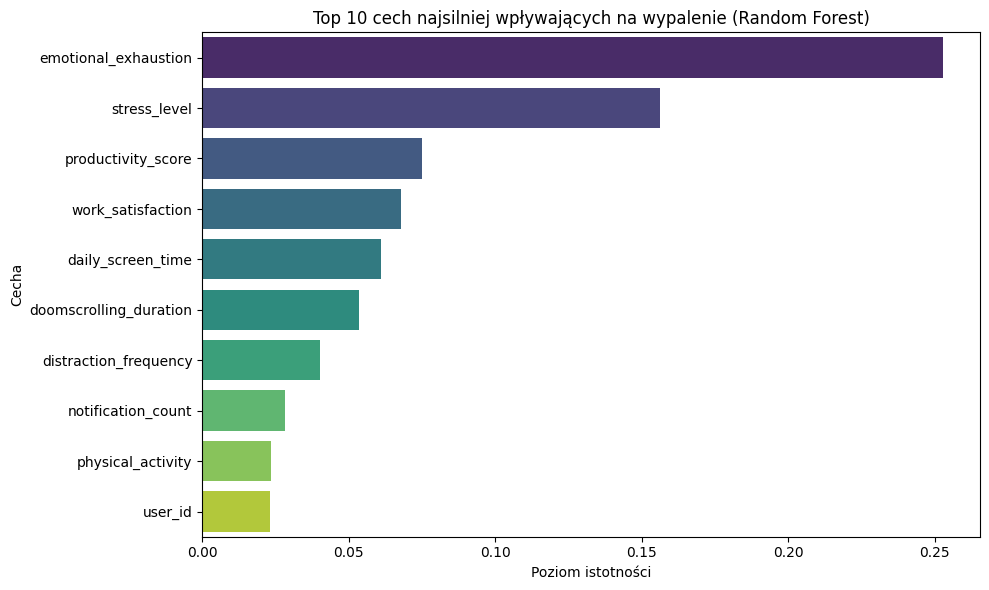


Top 10 najważniejszych cech:
                 Cecha  Istotność
  emotional_exhaustion   0.252883
          stress_level   0.156303
    productivity_score   0.074973
     work_satisfaction   0.068014
     daily_screen_time   0.061020
doomscrolling_duration   0.053664
 distraction_frequency   0.040078
    notification_count   0.028101
     physical_activity   0.023619
               user_id   0.023108


In [25]:
# --- KROK 6: Feature Importance — które cechy mają największy wpływ ---
importances = best_rf.feature_importances_
feature_names = X_final.columns

importance_df = pd.DataFrame({
    'Cecha': feature_names,
    'Istotność': importances
}).sort_values('Istotność', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Istotność', y='Cecha', palette='viridis')
plt.title('Top 10 cech najsilniej wpływających na wypalenie (Random Forest)')
plt.xlabel('Poziom istotności')
plt.tight_layout()
plt.show()

print("\nTop 10 najważniejszych cech:")
print(importance_df.to_string(index=False))

# WNIOSKI


1. Skuteczność modelu: RMSE = 14.05 — model myli się średnio o 14 punkty,
co jest znaczącą poprawą względem Hipotezy 1 (RMSE = 21.52).

2. Najlepsze hiperparametry znalezione przez Random Search:
n_estimators = 100, max_depth = None, min_samples_split = 5.

3. Najważniejsze cechy: Największy wpływ na wypalenie mają czynniki psychologiczne - wyczerpanie emocjonalne (25.3%) i poziom stresu (15.6%).
Aktywność fizyczna i sen mają zaskakująco mały wpływ (poniżej 3%).

4. Werdykt: Hipoteza potwierdzona. Użycie wszystkich zmiennych z standaryzacją
i One Hot Encoding znacząco poprawiło jakość modelu.